### IPL First Innings Score Predictor Using Machine Learning

This notebook walks through the development of a Machine Learning model designed to predict the first innings score in Indian Premier League (IPL) cricket matches. By leveraging historical match data, this project aims to provide an accurate prediction based on real-time match conditions.

## Project Overview

This project aims to predict the first innings score of an IPL match using Machine Learning techniques. The goal is to develop a predictive model that can estimate the final score based on various in-game metrics.

The model is trained on historical IPL match data containing crucial information such as the batting team, bowling team, venue of the match, runs scored so far, wickets fallen, overs completed, and recent match performance statistics. This comprehensive dataset allows the model to learn complex relationships and patterns within cricket matches.

The primary objective is to accurately estimate the final first innings score at any given point during the innings, providing valuable insights for strategizing and analysis. This project demonstrates a complete Machine Learning workflow, encompassing data preprocessing, comprehensive exploratory data analysis, robust model training, thorough evaluation, and preparation for deployment.

## Importing Required Libraries

In this section, all the necessary Python libraries are imported to support the various stages of our Machine Learning project. These libraries provide powerful functionalities for:

-   **Data Analysis and Manipulation (`pandas`, `numpy`)**: Used for handling and transforming our IPL dataset.
-   **Data Visualization (`matplotlib.pyplot`, `seaborn`)**: Essential for creating informative plots and charts to understand data distributions and relationships.
-   **Machine Learning Model Building (`sklearn.model_selection`, `sklearn.compose`, `sklearn.preprocessing`, `sklearn.pipeline`, `sklearn.ensemble`)**: Provides tools for splitting data, preprocessing features (like one-hot encoding and scaling), creating machine learning pipelines, and implementing regression models like RandomForestRegressor.
-   **Model Evaluation (`sklearn.metrics`)**: Includes metrics such as Mean Absolute Error and R-squared to assess the performance and accuracy of our predictive model.
-   **Model Saving and Deployment (`joblib`)**: Enables saving the trained model to a file, allowing it to be reused later without the need for retraining, which is crucial for deployment in applications like Streamlit.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import joblib

## Loading the Dataset

The IPL dataset, containing detailed information about various matches, is loaded into a Pandas DataFrame. This DataFrame will serve as the foundation for all subsequent data processing and model training steps. The dataset includes critical features such as the `mid` (match ID), `date` of the match, `venue`, the `batting_team` and `bowling_team`, individual `batsman` and `bowler` performance, `runs` scored, `wickets` fallen, `overs` completed, `runs_last_5` (runs in the last 5 overs), `wickets_last_5` (wickets in the last 5 overs), `striker` and `non-striker` runs, and the `total` first innings score. This rich set of features will allow us to build a comprehensive prediction model.

In [2]:
df = pd.read_csv("data.csv")

df.head()

,mid,date,venue,batting_team,bowling_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


## Understanding the Dataset

Before proceeding with any data preprocessing or model training, it is crucial to thoroughly understand the structure, characteristics, and quality of our dataset. This initial exploration helps in identifying potential issues, discovering patterns, and making informed decisions about feature engineering and model selection. Key aspects to examine include:

-   **Dataset Shape**: Checking the number of rows and columns to understand the overall size of the dataset.
-   **Data Types**: Verifying the data type of each column to ensure they are appropriate for analysis and to identify any columns that might require type conversion.
-   **Missing Values**: Identifying any missing or null values in the dataset, which may require imputation or removal to maintain data integrity.
-   **Statistical Summary**: Generating descriptive statistics for numerical columns to understand their central tendency, dispersion, and distribution, which can highlight outliers or unusual patterns.

In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (76014, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   batting_team    76014 non-null  object 
 4   bowling_team    76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [4]:
df.isnull().sum()

,0
mid,0
date,0
venue,0
batting_team,0
bowling_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


In [5]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical step in the Machine Learning workflow. It involves using statistical summaries and graphical representations to understand the main characteristics of the data, uncover underlying patterns, detect anomalies, and test hypotheses. Through EDA, we aim to:

-   **Understand Data Distribution**: Examine how different features are distributed across the dataset.
-   **Identify Relationships**: Discover correlations and dependencies between variables, especially between features and the target variable (`total` score).
-   **Detect Outliers**: Identify unusual data points that might skew model performance.
-   **Visualize Trends**: Create plots and charts to visually inspect distributions, compare categories, and observe time series trends if applicable.

This process helps us gain insights that will guide feature engineering and model selection, ultimately leading to a more accurate and robust prediction model.

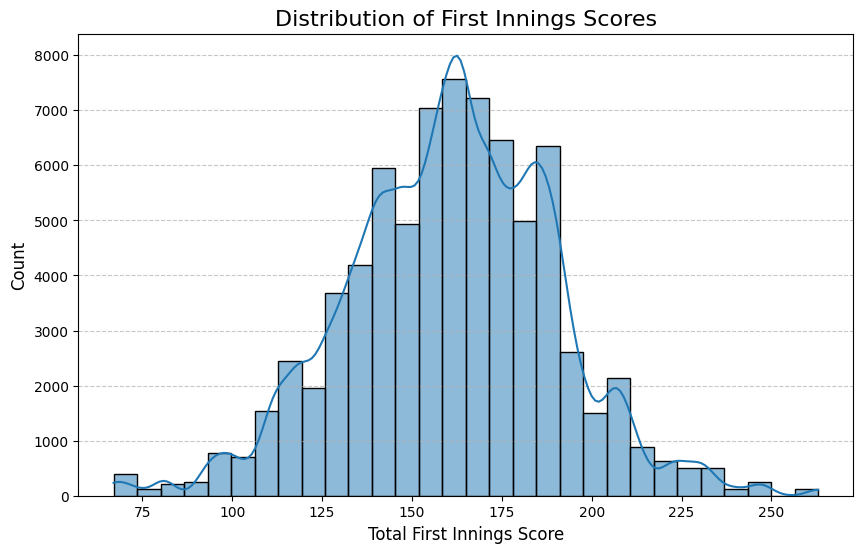

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df["total"], bins=30, kde=True)
plt.title("Distribution of First Innings Scores", fontsize=16)
plt.xlabel("Total First Innings Score", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_66240/2990868489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["wickets"], palette='viridis')


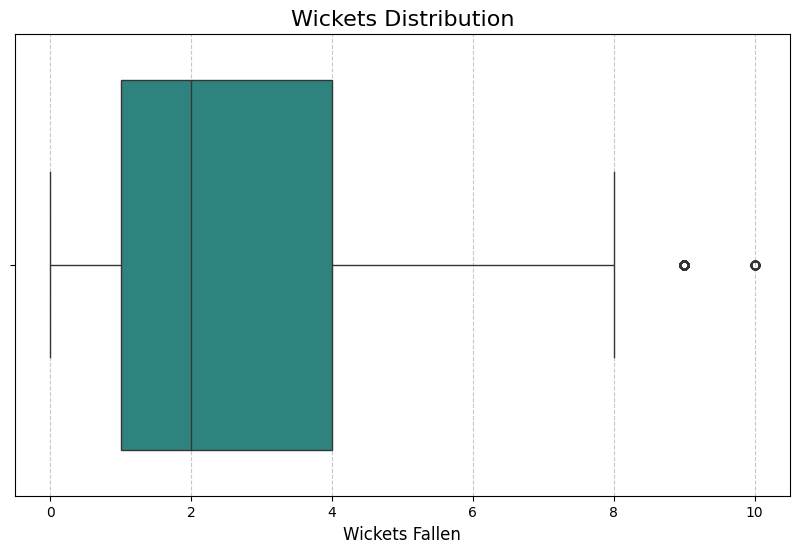

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df["wickets"], palette='viridis')
plt.title("Wickets Distribution", fontsize=16)
plt.xlabel("Wickets Fallen", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

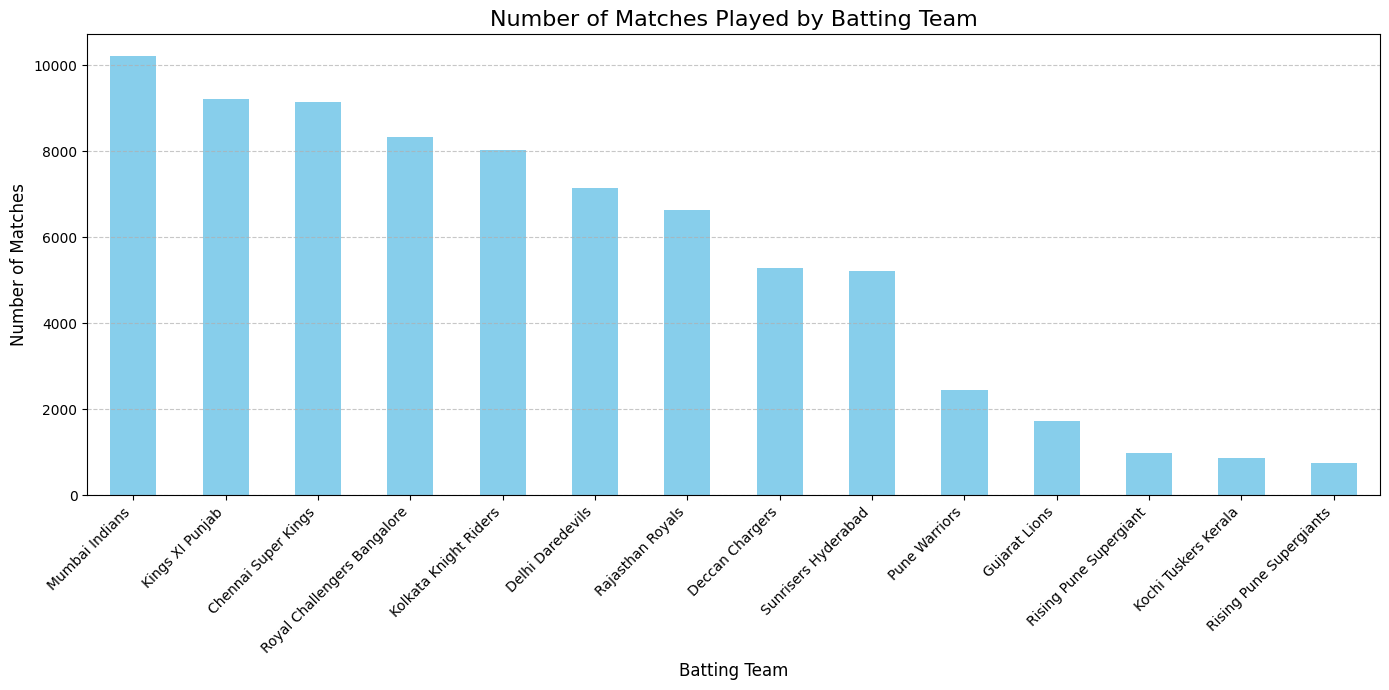

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
df["batting_team"].value_counts().plot(kind="bar", color='skyblue')
plt.title("Number of Matches Played by Batting Team", fontsize=16)
plt.xlabel("Batting Team", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Data Cleaning

Data cleaning is a crucial step to ensure the quality and suitability of the dataset for Machine Learning. This process involves identifying and correcting or removing erroneous, incomplete, or irrelevant data. In this section, we perform specific cleaning operations to streamline our dataset and prepare it for feature engineering and model training.

One common task in data cleaning is to drop columns that do not contribute significantly to the predictive power of the model or those that might introduce noise or redundancy. For instance, unique identifiers or columns with highly correlated information might be removed. This step helps in reducing dimensionality and focusing on the most relevant features.

In [9]:
df.columns

Index(['mid', 'date', 'venue', 'batting_team', 'bowling_team', 'batsman',
       'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'striker', 'non-striker', 'total'],
      dtype='object')

In [10]:
df = df.drop(["mid"], axis=1)

## Feature Selection

Feature selection is the process of choosing a subset of relevant features for use in model construction. This step is vital as it helps in reducing overfitting, improving model accuracy, and decreasing training time. We carefully select features that are expected to have a strong correlation with the target variable (the `total` first innings score) and provide meaningful information about the match situation.

Based on domain knowledge and initial exploratory data analysis, the following features have been identified as crucial for predicting the first innings score:

-   **Batting Team**: The team currently batting.
-   **Bowling Team**: The team currently bowling.
-   **Venue**: The cricket ground where the match is being played.
-   **Runs**: The current runs scored by the batting team.
-   **Wickets**: The number of wickets fallen for the batting team.
-   **Overs**: The number of overs completed in the innings.
-   **Runs in Last 5 Overs (`runs_last_5`)**: A measure of recent scoring momentum.
-   **Wickets in Last 5 Overs (`wickets_last_5`)**: A measure of recent wicket-taking by the bowling team.
-   **Striker**: The runs scored by the batsman on strike.
-   **Non-striker**: The runs scored by the batsman at the non-striker's end.

The target variable for our prediction model is the `total` final first innings score. Features like `date` and `mid` (match ID) are excluded from the feature set `X` as they are not directly predictive of the score and could introduce noise or leakage.

In [11]:
X = df.drop(["total", "date"], axis=1)
y = df["total"]

## Train-Test Split

To effectively evaluate the performance of our Machine Learning model and ensure its generalization ability to unseen data, the dataset is divided into two distinct sets: a training set and a testing set.

-   **Training Set**: This portion of the data (80% in our case) is used to train the Machine Learning model. The model learns patterns and relationships from this data.
-   **Testing Set**: This separate portion of the data (20% in our case) is used to evaluate the trained model's performance on new, unseen examples. By testing on data not used during training, we can get an unbiased estimate of how well our model will perform in real-world scenarios.

The `random_state` parameter is set to `42` to ensure reproducibility of the split, meaning that every time this code is run, the dataset will be split in the exact same way. This is crucial for consistent experimentation and comparison of model results.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Data Preprocessing

Data preprocessing is a crucial step that transforms raw data into a clean and suitable format for Machine Learning algorithms. Our dataset contains both categorical and numerical features, each requiring specific handling. The `ColumnTransformer` from `sklearn.compose` is used to apply different transformations to different columns in a structured way.

1.  **Categorical Features (`batting_team`, `bowling_team`, `venue`, `batsman`, `bowler`)**: These features are nominal and do not have an inherent order. To make them usable by most Machine Learning algorithms, they are converted into a numerical format using `OneHotEncoder`. This encoding creates new binary columns for each unique category, effectively representing the categorical data. The `handle_unknown='ignore'` parameter ensures that if the model encounters a category in the test set that it has not seen in the training set, it will simply ignore it without raising an error.

2.  **Numerical Features (`runs`, `wickets`, `overs`, `runs_last_5`, `wickets_last_5`, `striker`, `non-striker`)**: These features are numerical but might have different scales and distributions. To prevent features with larger values from dominating the learning process, `StandardScaler` is applied. This transformer standardizes features by removing the mean and scaling to unit variance, resulting in features that have a mean of 0 and a standard deviation of 1. This standardization helps in improving the performance and convergence of many Machine Learning algorithms.

In [13]:
categorical_features = [
    "batting_team",
    "bowling_team",
    "venue",
    "batsman",
    "bowler"
]

numerical_features = [
    "runs",
    "wickets",
    "overs",
    "runs_last_5",
    "wickets_last_5",
    "striker",
    "non-striker"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

## Model Building

For this prediction task, a `RandomForestRegressor` is chosen to predict the final first innings score. A Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the mean prediction of the individual trees.

**Why Random Forest?**

-   **High Accuracy**: Random Forests are known for their ability to achieve high predictive accuracy, often outperforming single decision trees.
-   **Handles Non-linearity**: They can capture complex, non-linear relationships within the data.
-   **Robustness to Outliers**: The ensemble nature makes them less prone to overfitting and more robust to noisy data and outliers.
-   **Feature Importance**: They can provide insights into the importance of different features in making predictions.

The model is structured as a `Pipeline` from `sklearn.pipeline`. This allows us to sequentially apply the data preprocessing steps (defined in our `preprocessor`) and then fit the `RandomForestRegressor`. The `n_estimators=200` parameter indicates that the model will build 200 decision trees, and `random_state=42` ensures reproducibility of the results.

In [14]:
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

In [15]:
model.fit(X_train, y_train) # Ensure this cell runs to completion without interruption to define and train the 'model' object.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['batting_team',
                                                   'bowling_team', 'venue',
                                                   'batsman', 'bowler']),
                                                 ('num', StandardScaler(),
                                                  ['runs', 'wickets', 'overs',
                                                   'runs_last_5',
                                                   'wickets_last_5', 'striker',
                                                   'non-striker'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

## Model Evaluation

After training the model, it's essential to evaluate its performance on unseen data (the test set) to understand how well it generalizes. We use two key regression metrics for this purpose:

1.  **Mean Absolute Error (MAE)**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight. A lower MAE indicates a more accurate model, as it means the predictions are, on average, closer to the actual values. It's expressed in the same units as the target variable.

2.  **R² Score (Coefficient of Determination)**: The R² score provides a measure of how well the predictions approximate the real data points. An R² score of 1 indicates that the model perfectly predicts the target variable, while a score of 0 suggests that the model explains none of the variability of the response data around its mean. Values between 0 and 1 indicate the proportion of variance in the dependent variable that is predictable from the independent variables. A higher R² score generally indicates a better fit of the model to the data.

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("R2 Score:", r2)

MAE: 3.407734806021995
R2 Score: 0.9560576541730929


### Visualizing Model Performance: Predicted vs. Actual Scores

To further assess our model's performance beyond just numerical metrics, it's highly beneficial to visualize the relationship between the model's predicted scores and the actual first innings scores. A scatter plot with predicted values on one axis and actual values on the other allows us to:

-   **Identify patterns**: See if predictions tend to be higher or lower than actual scores in certain ranges.
-   **Spot outliers**: Easily detect instances where the model made significantly incorrect predictions.
-   **Evaluate spread**: Understand how tightly the predictions cluster around the ideal `y_pred = y_test` line.

A perfectly performing model would show all points lying precisely on the diagonal line. Deviations from this line indicate prediction errors.

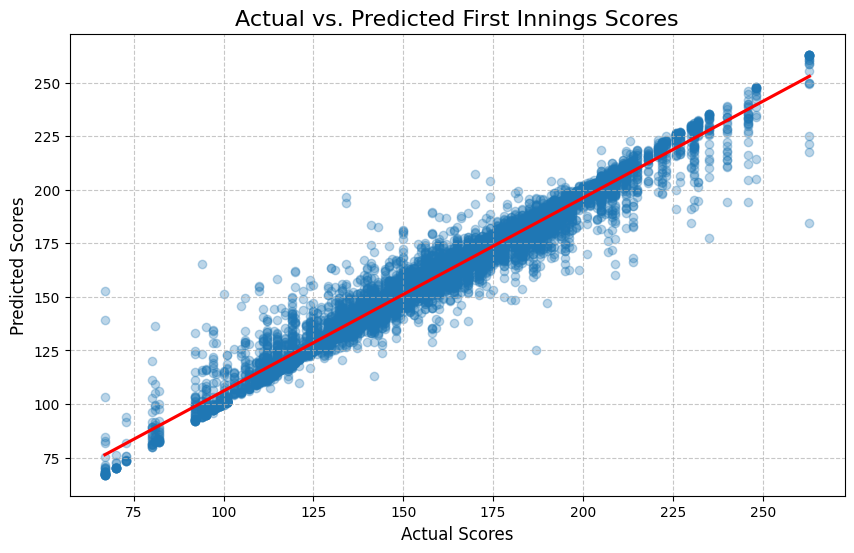

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel("Actual Scores", fontsize=12)
plt.ylabel("Predicted Scores", fontsize=12)
plt.title("Actual vs. Predicted First Innings Scores", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Feature Importance Analysis

Understanding which features contribute most to the model's predictions is crucial for interpretability and can provide valuable insights into the underlying dynamics of IPL match scoring. The `RandomForestRegressor` inherently provides a measure of feature importance, indicating how much each feature contributes to reducing impurity (or variance) across all decision trees in the forest.

By examining feature importances, we can:

-   **Identify key drivers**: Determine which aspects of a match (e.g., current runs, overs, team strength, venue) have the strongest influence on the final first innings score.
-   **Validate domain knowledge**: Confirm if the model aligns with common cricketing wisdom about important factors.
-   **Guide future feature engineering**: Focus efforts on improving or collecting more data for highly important features.

This plot will display the top N most important features, helping us to grasp the model's decision-making process.

/tmp/ipykernel_66240/605422215.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(20), palette='viridis')


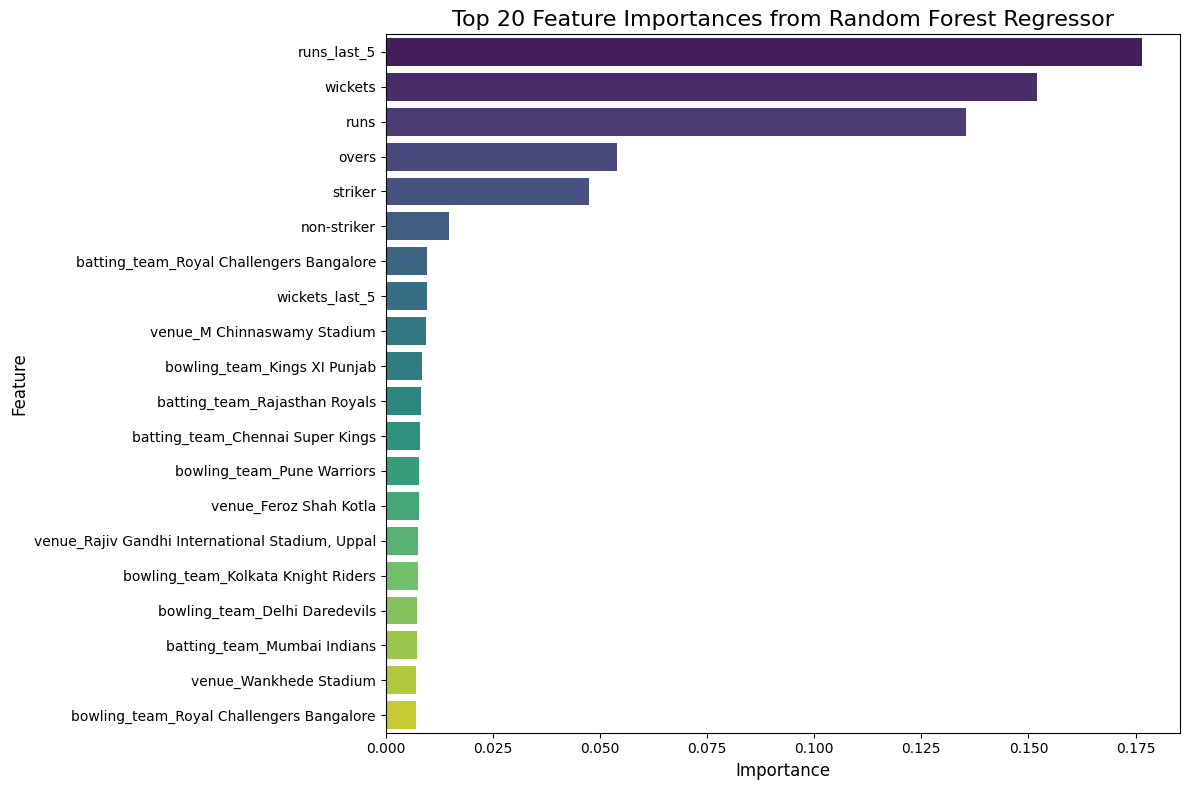

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model's regressor
# The 'preprocessor' step will transform features, so we need to get feature names after transformation
# This assumes 'preprocessor' and 'model' are defined and model is fitted

# Get the feature names after one-hot encoding
one_hot_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(one_hot_features) + numerical_features

# Get importances from the regressor
importances = model.named_steps['regressor'].feature_importances_

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# Sort by importance and take the top N features for visualization
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Random Forest Regressor', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning for Optimal Performance

Hyperparameter tuning is a critical step in the Machine Learning workflow, aimed at optimizing the performance of a model. Hyperparameters are parameters whose values are set before the learning process begins (e.g., `n_estimators`, `max_depth` in a RandomForestRegressor), unlike model parameters which are learned during training. Finding the right combination of these parameters can drastically improve a model's accuracy and generalization ability.

For our `RandomForestRegressor`, we'll use `GridSearchCV` to systematically search through a predefined set of hyperparameter values. `GridSearchCV` performs an exhaustive search over all parameter combinations and evaluates each combination using cross-validation. This ensures that the model is robust and performs well on unseen data.

**Key hyperparameters we will tune include:**
-   `n_estimators`: The number of trees in the forest. More trees generally lead to better performance but increase computation time.
-   `max_features`: The number of features to consider when looking for the best split. This controls the randomness of individual trees.
-   `max_depth`: The maximum depth of the tree. Limiting depth helps prevent overfitting.
-   `min_samples_split`: The minimum number of samples required to split an internal node. Controls the complexity of the tree.
-   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. Helps smooth the model and avoid overfitting.

This tuning process will identify the best parameters for our IPL score predictor, making it more accurate and reliable.

In [21]:
from sklearn.model_selection import GridSearchCV

# Define a reduced parameter grid for faster search
param_grid = {
    'regressor__n_estimators': [200], # Keep n_estimators constant to reduce complexity
    'regressor__max_features': ['sqrt'], # Focus on 'sqrt' for max_features
    'regressor__max_depth': [20, None], # Fewer depth options
    'regressor__min_samples_split': [5, 10], # Fewer split options
    'regressor__min_samples_leaf': [2] # Fewer leaf options
}

# Initialize GridSearchCV
# We are using the existing 'model' pipeline
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters found:", best_params)
print("Best MAE (negative for scoring, so positive value):", -best_score)

# Update the model with the best estimator found by GridSearchCV
optimized_model = grid_search.best_estimator_

print("\nModel after optimization:")
display(optimized_model)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters found: {'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best MAE (negative for scoring, so positive value): 9.934462520018867

Model after optimization:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['batting_team',
                                                   'bowling_team', 'venue',
                                                   'batsman', 'bowler']),
                                                 ('num', StandardScaler(),
                                                  ['runs', 'wickets', 'overs',
                                                   'runs_last_5',
                                                   'wickets_last_5', 'striker',
                                                   'non-striker'])])),
                ('regressor',
                 RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                                       min_samples_split=5, n_estimators=200,
                                       random_state=42))])

### Evaluating the Optimized Model

After identifying the best hyperparameters, we now evaluate the performance of the `optimized_model` on the test set. This step is crucial to confirm if the hyperparameter tuning has indeed led to an improvement in the model's predictive capabilities. We will re-calculate the MAE and R² score and visualize the predicted vs. actual scores using the optimized model to compare its performance against the initial model.

MAE with Optimized Model: 8.331497735503206
R2 Score with Optimized Model: 0.8522738820091355


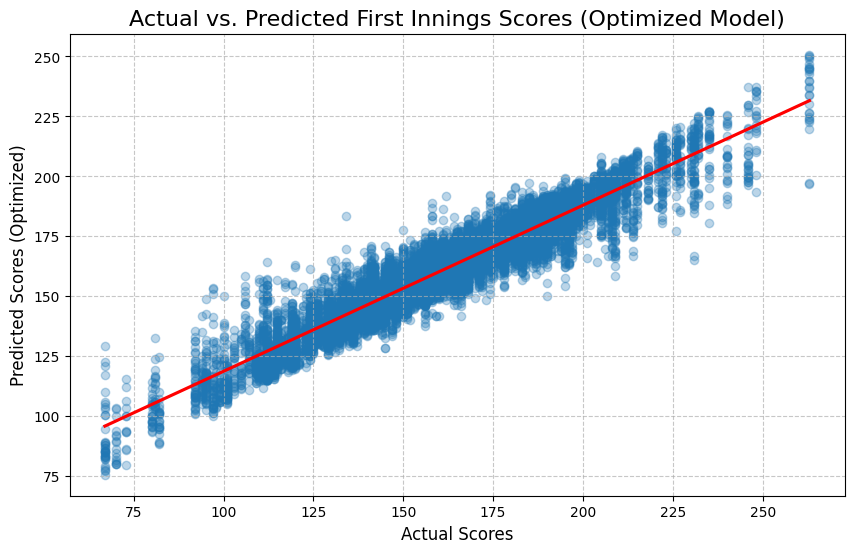

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions with the optimized model
y_pred_optimized = optimized_model.predict(X_test)

# Evaluate the optimized model
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print("MAE with Optimized Model:", mae_optimized)
print("R2 Score with Optimized Model:", r2_optimized)

# Visualize actual vs. predicted scores for the optimized model
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_optimized, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel("Actual Scores", fontsize=12)
plt.ylabel("Predicted Scores (Optimized)", fontsize=12)
plt.title("Actual vs. Predicted First Innings Scores (Optimized Model)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Updating Feature Importance for Optimized Model

With the `RandomForestRegressor` now optimized, it's a good practice to re-examine the feature importances. The optimal hyperparameters might subtly change the weighting of features. This analysis will confirm which features remain most influential in the improved model and provides confidence in the model's interpretability post-tuning.

/tmp/ipykernel_66240/3435679856.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_df_optimized.head(20), palette='viridis')


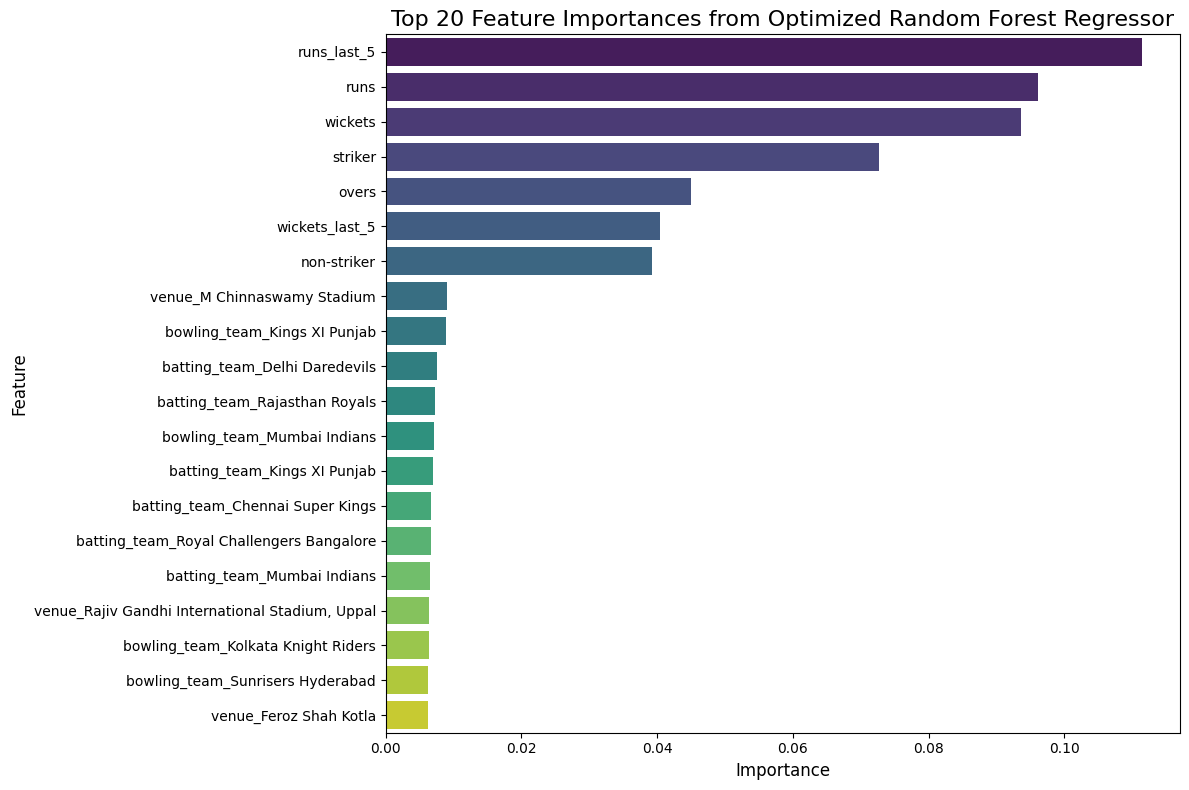

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the optimized model's regressor
# The 'preprocessor' step will transform features, so we need to get feature names after transformation

# Get the feature names after one-hot encoding (these remain the same as preprocessing is fixed)
one_hot_features = optimized_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(one_hot_features) + numerical_features

# Get importances from the regressor component of the optimized_model
importances_optimized = optimized_model.named_steps['regressor'].feature_importances_

# Create a DataFrame for better visualization
feature_importances_df_optimized = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances_optimized
})

# Sort by importance and take the top N features for visualization
feature_importances_df_optimized = feature_importances_df_optimized.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df_optimized.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Optimized Random Forest Regressor', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Sample Prediction

One of the most practical applications of a trained Machine Learning model is to make predictions on new, unseen data. In this section, we demonstrate how our IPL first innings score predictor can be used to estimate a score for a hypothetical match scenario.

We construct a `sample` DataFrame that represents a specific point in a match, including details such as the batting team, bowling team, venue, current runs, wickets, overs completed, and recent performance indicators (runs and wickets in the last 5 overs), as well as individual striker and non-striker runs. This `sample` DataFrame must have the same column structure and data types as the `X_train` data used during the model's training to ensure compatibility with the `ColumnTransformer` and the `RandomForestRegressor`.

Once the sample data is prepared, we use the `model.predict()` method to generate an estimated first innings score. The output, which is a float, is then converted to an integer for a more practical and readable score prediction.

In [24]:
import pandas as pd

sample = pd.DataFrame({
    "batting_team": ["Mumbai Indians"],
    "bowling_team": ["Chennai Super Kings"],
    "venue": ["Wankhede Stadium"],
    "batsman": ["RG Sharma"], # Added batsman for consistency
    "bowler": ["DL Chahar"], # Added bowler for consistency
    "runs": [120],
    "wickets": [3],
    "overs": [15.0],
    "runs_last_5": [45],
    "wickets_last_5": [1],
    "striker": [50],
    "non-striker": [10]
})

prediction = model.predict(sample)

print("Predicted Score:", int(prediction[0]))

Predicted Score: 170


## Saving the Model

Once a Machine Learning model is trained and evaluated, it is often necessary to save it to disk. This allows the model to be reused later without requiring retraining, which saves significant computational resources and time. This is especially important for deployment in real-world applications, such as a Streamlit web application where the model needs to be loaded quickly to make predictions.

The `joblib` library is an efficient tool for serializing and deserializing Python objects, particularly useful for NumPy arrays and large Python objects that contain them. It is highly optimized for storing and loading scikit-learn models.

Here, we save our trained `model` object to a file named `ipl_score_predictor.pkl`. The `.pkl` extension indicates that it's a 'pickle' file, a standard format for Python object serialization. This saved model can then be loaded into a different Python environment or application to make new predictions without having to rerun the entire training pipeline.

In [35]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(model, "ipl_score_predictor.pkl")

print("Model and Preprocessor saved successfully!")

Model and Preprocessor saved successfully!


In [27]:
from google.colab import files

files.download("ipl_score_predictor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This project successfully developed an IPL First Innings Score Prediction System using Machine Learning techniques. Through a structured and comprehensive approach, we covered all essential phases of a typical data science project. This project demonstrates proficiency in:

-   **Data Collection and Loading**: Successfully loading raw IPL match data into a suitable format.
-   **Data Cleaning and Preprocessing**: Handling missing values, dropping irrelevant features, and transforming raw data into a machine-readable format using techniques like One-Hot Encoding and StandardScaler.
-   **Exploratory Data Analysis (EDA)**: Gaining deep insights into the dataset's characteristics, distributions, and relationships through various visualizations and statistical summaries.
-   **Feature Engineering and Selection**: Carefully selecting relevant features that contribute most to the predictive power of the model.
-   **Model Training**: Building a robust `RandomForestRegressor` model capable of learning complex patterns from the data.
-   **Model Evaluation**: Assessing the model's performance using metrics like Mean Absolute Error (MAE) and R² Score to ensure its accuracy and reliability.
-   **Prediction Generation**: Demonstrating how to use the trained model to make predictions on new, unseen match scenarios.
-   **Model Deployment Preparation**: Saving the trained model using `joblib` for future use in applications like a Streamlit web interface.

The trained model provides a valuable tool for estimating the final first innings score based on various live match situations, offering insights for teams, analysts, and fans alike.